### **ADAptive LInear NEuron (Adaline)**

<p align="center">
  <img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/main/ch02/figures/02_09.png" width="600">
</p>

### **Adaptive Linear Neurons (Adaline) & Gradient Descent**

**1. The Linear Activation Function**

Unlike the perceptron, Adaline updates weights based on a linear activation function, which is simply the identity function of the net input $z$:
$$\sigma(z) = z$$
Where the net input is a real number defined as:
$$z^{(i)} = \mathbf{w}^T\mathbf{x}^{(i)} + b$$


**2. The Objective Function: Mean Squared Error (MSE)**

To learn the model parameters, we minimize a continuous, convex loss function $L$. For Adaline, this is the Mean Squared Error between the calculated outcome and the true class label:
$$L(\mathbf{w}, b) = \frac{1}{n} \sum_{i=1}^{n} \left(y^{(i)} - \sigma(z^{(i)})\right)^2$$


**3. Minimizing Loss with Gradient Descent**

We update the model parameters by taking a step in the opposite direction of the gradient, $\nabla L(\mathbf{w}, b)$, of our loss function.
The general update rule is:
$$\mathbf{w} := \mathbf{w} + \Delta\mathbf{w}, \quad b := b + \Delta b$$
The parameter changes, $\Delta\mathbf{w}$ and $\Delta b$, are defined as the negative gradient multiplied by the learning rate, $\eta$:
$$\Delta\mathbf{w} = -\eta \nabla_{\mathbf{w}} L(\mathbf{w}, b), \quad \Delta b = -\eta \nabla_b L(\mathbf{w}, b)$$

So, the weight and bias updates can be written as:
$$\Delta w_j = -\eta \frac{\partial L}{\partial w_j} \quad \text{and} \quad \Delta b = -\eta \frac{\partial L}{\partial b}$$
  
**4. Partial Derivatives of the Loss Function**

To compute the gradient, we calculate the partial derivative of the loss function with respect to each weight, $w_j$:
$$\frac{\partial L}{\partial w_j} = -\frac{2}{n} \sum_{i} \left(y^{(i)} - \sigma(z^{(i)})\right) x_j^{(i)}$$
Similarly, we compute the partial derivative of the loss with respect to the bias as:
$$\frac{\partial L}{\partial b} = -\frac{2}{n} \sum_{i} \left(y^{(i)} - \sigma(z^{(i)})\right)$$
*(Note: The $2/n$ scaling factor is often omitted in practice as it can be absorbed into the learning rate $\eta$.)*

**Source:** https://github.com/rasbt/machine-learning-book/blob/main/ch02/ch02.ipynb

In [1]:
class AdalineGD:
  """ADaptive LInear NEuron classifier.

  Parameters
  ----------
  eta : float
    Learning rate (between 0.0 and 1.0)
  n_iter : int
    Passes over the training dataset.
  random_state : int
    Random number generator seed for random weight initilization.

  Attributes
  ----------
  w_ : 1d-array
    Weights after fitting.
  b_ : Scalar
    Bias unit after fitting.
  losses_ : list
    Mean sqaured error loss function values in each epoch.
  """

  def __init__(self, eta=0.01, n_iter=50, random_state=1):
    self.eta = eta
    self.n_iter = n_iter
    self.random_state = random_state

  def fit(self, X, y):
    """Fit training data.

    Paramaters
    ----------
    X : {array-like}, shape = [n_example, n_features]
        Training vectors, where n_examples
        is the number of examples and n_features
        is the number of features.
    y : array-like, shape = [n_examples]
        Target values.

    Returns
    -------
    self : object
    """

    rgen = np.random.RandomState(self.random_state)
    self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
    self.b_ = np.float64(0.)
    self.losses_ = []

    for i in range(self.n_iter):
      net_input = self.net_input(X)
      output = self.activation(net_input)
      errors = (y - output)
      self.w_ += self.eta * 2.0 * X.T.dot(errors) / X.shape[0]
      self.b_ += self.eta * 2.0 * errors.mean()
      loss = (errors**2).mean()
      self.losses_.append(loss)
    return self

  def net_input(self, X):
    """Calculate net input"""
    return np.dot(X, self.w_) + self.b_

  def activation(self, X):
    """Compute linear activation"""
    return X

  def predict(self, X):
    """Return class label after unit step"""
    return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0)

In [2]:
import os
import pandas as pd


s = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
print('From URL:', s)
df = pd.read_csv(s,
                 header=None,
                 encoding='utf-8')

df.tail()

From URL: https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data


,0,1,2,3,4
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


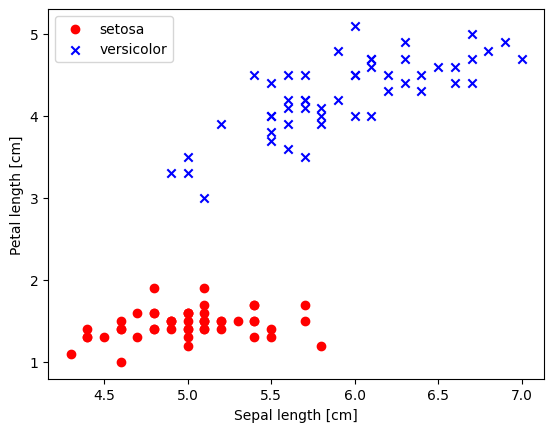

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# select Setosa and Versicolor
y = df.iloc[0:100, 4].values
y = np.where(y == 'Iris-setosa', 0, 1)

# extract sepal lenght and petal length
X = df.iloc[0:100, [0, 2]].values

# plot data
plt.scatter(X[:50, 0], X[:50, 1],
            color='red',
            marker='o',
            label='setosa')
plt.scatter(X[50:100, 0], X[50:100, 1],
            color='blue',
            marker='x',
            label='versicolor')

plt.xlabel('Sepal length [cm]')
plt.ylabel('Petal length [cm]')
plt.legend(loc='upper left')

plt.show()

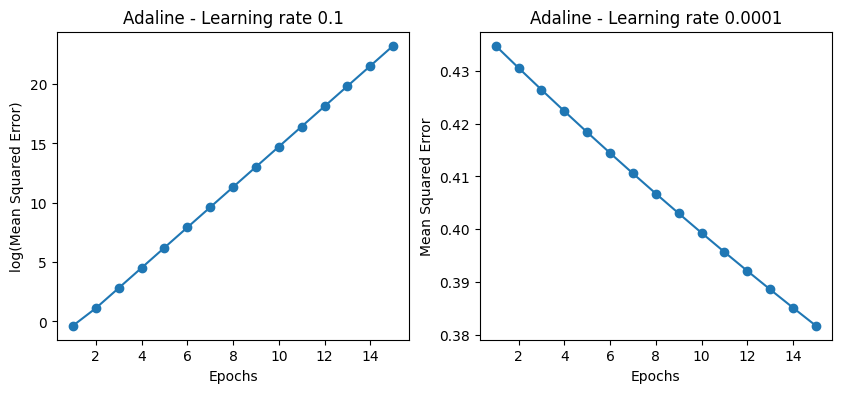

In [4]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

ada1 = AdalineGD(n_iter=15, eta=0.1).fit(X, y)
ax[0].plot(range(1, len(ada1.losses_) + 1), np.log10(ada1.losses_), marker='o')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('log(Mean Squared Error)')
ax[0].set_title('Adaline - Learning rate 0.1')

ada2 = AdalineGD(n_iter=15, eta=0.0001).fit(X, y)
ax[1].plot(range(1, len(ada2.losses_) + 1), ada2.losses_, marker='o')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Mean Squared Error')
ax[1].set_title('Adaline - Learning rate 0.0001')

plt.show()